100%|██████████| 10000/10000 [04:28<00:00, 37.28it/s]



Metriche Bootstrap:
Training Accuracy: 1.0000 ± 0.0000
Validation Accuracy: 0.8780 ± 0.0427
Test Accuracy: 0.8046 ± 0.1302
Precision: 0.8408 ± 0.1199
Recall: 0.8046 ± 0.1302
F1-score: 0.7959 ± 0.1384

Overfitting Gap (Train - Validation): 0.1220
Overfitting Gap (Validation - Test): 0.0733


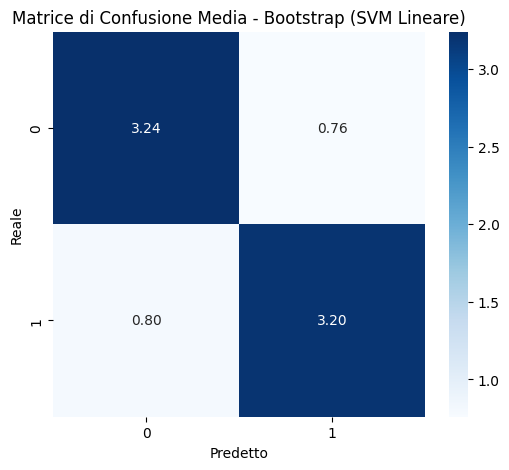

In [1]:
# Ricaricare le librerie necessarie
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import ast

# Caricamento dati
file_path = "./pre_processing_output/snare_classification_nodes.csv"
df = pd.read_csv(file_path)
df["GO_embeddings"] = df["GO_embeddings"].apply(ast.literal_eval)
embeddings_df = pd.DataFrame(df["GO_embeddings"].tolist())

X = embeddings_df
y = df["LABEL"]

# Suddivisione del dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

# Parametri
n_iterations = 10000
accuracy_train_scores = []
accuracy_val_scores = []
accuracy_test_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
conf_matrices = []

# Bootstrap con SVM lineare
for _ in tqdm(range(n_iterations)):
    # Resample del training set
    X_boot, y_boot = resample(X_train, y_train, replace=True)
    
    # Modello SVM con kernel lineare
    svm_model_boot = SVC(kernel="linear", C=10, class_weight="balanced")
    svm_model_boot.fit(X_boot, y_boot)
    
    # Accuracy train e validation
    train_acc = svm_model_boot.score(X_boot, y_boot)
    accuracy_train_scores.append(train_acc)
    
    val_acc = svm_model_boot.score(X_val, y_val)
    accuracy_val_scores.append(val_acc)

    # Predizione e metriche sul test set
    y_pred = svm_model_boot.predict(X_test)
    
    test_acc = accuracy_score(y_test, y_pred)
    accuracy_test_scores.append(test_acc)
    
    precision_scores.append(precision_score(y_test, y_pred, average="weighted", zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, average="weighted", zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, average="weighted", zero_division=0))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

# Risultati medi
results = {
    "Training Accuracy": (np.mean(accuracy_train_scores), np.std(accuracy_train_scores)),
    "Validation Accuracy": (np.mean(accuracy_val_scores), np.std(accuracy_val_scores)),
    "Test Accuracy": (np.mean(accuracy_test_scores), np.std(accuracy_test_scores)),
    "Precision": (np.mean(precision_scores), np.std(precision_scores)),
    "Recall": (np.mean(recall_scores), np.std(recall_scores)),
    "F1-score": (np.mean(f1_scores), np.std(f1_scores))
}

conf_matrix_mean = np.mean(conf_matrices, axis=0)

# Stampa metriche
print("\nMetriche Bootstrap:")
for metric, values in results.items():
    print(f"{metric}: {values[0]:.4f} ± {values[1]:.4f}")

# Controllo Overfitting
overfitting_gap_train_val = results["Training Accuracy"][0] - results["Validation Accuracy"][0]
overfitting_gap_val_test = results["Validation Accuracy"][0] - results["Test Accuracy"][0]

print(f"\nOverfitting Gap (Train - Validation): {overfitting_gap_train_val:.4f}")
print(f"Overfitting Gap (Validation - Test): {overfitting_gap_val_test:.4f}")

# Matrice di confusione media
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_mean, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione Media - Bootstrap (SVM Lineare)")
plt.show()


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Migliori parametri trovati:
{'C': 1, 'class_weight': 'balanced', 'gamma': 0.001, 'kernel': 'rbf'}

Metriche sul test set:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000


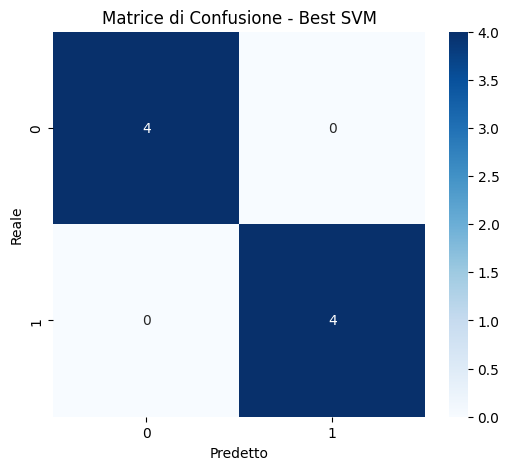

In [5]:
# Ricaricare le librerie necessarie
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import ast

# Caricamento dati
df = pd.read_csv('./pre_processing_output/snare_classification_nodes.csv')
df["GO_embeddings"] = df["GO_embeddings"].apply(ast.literal_eval)
embeddings_df = pd.DataFrame(df["GO_embeddings"].tolist())
X = embeddings_df
y = df["LABEL"]

# Split del dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

# Griglia dei parametri per la SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.001, 0.0001],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

# Grid Search con validazione incrociata (5-fold)
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='f1_weighted', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print("Migliori parametri trovati:")
print(grid_search.best_params_)

# Valutazione finale sul test set
best_model = grid_search.best_estimator_

y_pred_test = best_model.predict(X_test)

# Metriche finali
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
conf_matrix = confusion_matrix(y_test, y_pred_test)

print(f"\nMetriche sul test set:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")

# Matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione - Best SVM")
plt.show()


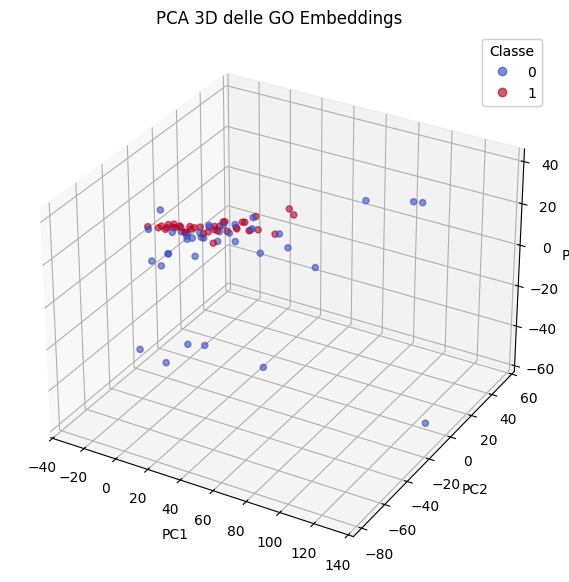

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # importa modulo per grafici 3D

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='coolwarm', alpha=0.6)
legend = ax.legend(*scatter.legend_elements(), title="Classe")
ax.add_artist(legend)
ax.set_title("PCA 3D delle GO Embeddings")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()


/home/developer/Documents/Tesi/code_old/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


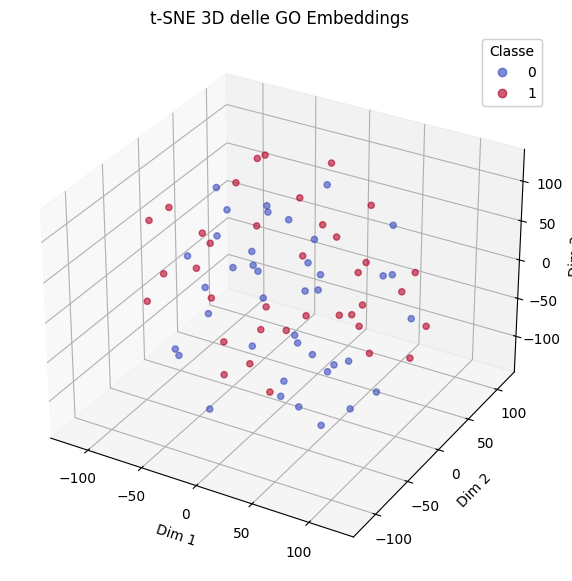

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

tsne = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)
X_tsne_3d = tsne.fit_transform(X)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=y, cmap='coolwarm', alpha=0.6)
legend = ax.legend(*scatter.legend_elements(), title="Classe")
ax.add_artist(legend)
ax.set_title("t-SNE 3D delle GO Embeddings")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
plt.show()


In [8]:
import plotly.express as px
from sklearn.decomposition import PCA
import pandas as pd

# PCA
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X)

# DataFrame per plotly
pca_df = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
pca_df["label"] = y.values

# Grafico 3D interattivo
fig = px.scatter_3d(
    pca_df, x="PC1", y="PC2", z="PC3",
    color="label", title="PCA 3D - Plotly", opacity=0.6
)

# Imposta dimensioni personalizzate
fig.update_layout(
    height=800,  # aumenta l'altezza (default ~450)
    width=1000   # opzionale: puoi anche aumentare la larghezza
)

fig.show()
